In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os
import pandas as pd

zip_path = '/content/drive/MyDrive/unemployment dataset.zip'
extract_dir = '/tmp/unemployment_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f'Files extracted to: {extract_dir}')


Files extracted to: /tmp/unemployment_data


In [3]:
# List the contents of the extracted directory to identify the data file
print('Contents of extracted directory:')
print(os.listdir(extract_dir))


Contents of extracted directory:
['unemployment analysis.csv']


Please examine the output of the previous cell to identify the main data file (e.g., a `.csv` or `.xlsx` file). Then, I can proceed to load it into a pandas DataFrame.

In [4]:
file_path = os.path.join(extract_dir, 'unemployment analysis.csv')
df = pd.read_csv(file_path)

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Information:")
df.info()

First 5 rows of the DataFrame:
                  Country Name Country Code   1991   1992   1993   1994  \
0  Africa Eastern and Southern          AFE   7.80   7.84   7.85   7.84   
1                  Afghanistan          AFG  10.65  10.82  10.72  10.73   
2   Africa Western and Central          AFW   4.42   4.53   4.55   4.54   
3                       Angola          AGO   4.21   4.21   4.23   4.16   
4                      Albania          ALB  10.31  30.01  25.26  20.84   

    1995   1996   1997   1998  ...   2012   2013   2014   2015   2016   2017  \
0   7.83   7.84   7.86   7.81  ...   6.56   6.45   6.41   6.49   6.61   6.71   
1  11.18  10.96  10.78  10.80  ...  11.34  11.19  11.14  11.13  11.16  11.18   
2   4.53   4.57   4.60   4.66  ...   4.64   4.41   4.69   4.63   5.57   6.02   
3   4.11   4.10   4.09   4.07  ...   7.35   7.37   7.37   7.39   7.41   7.41   
4  14.61  13.93  16.88  20.05  ...  13.38  15.87  18.05  17.19  15.42  13.62   

    2018   2019   2020   2021  
0   6

### Data Preprocessing

I will now preprocess the data by checking for and removing duplicate rows and handling any null values.

In [5]:
# Check for and remove duplicate rows
print(f"Number of rows before removing duplicates: {df.shape[0]}")
df.drop_duplicates(inplace=True)
print(f"Number of rows after removing duplicates: {df.shape[0]}")


Number of rows before removing duplicates: 235
Number of rows after removing duplicates: 235


In [6]:
# Check for null values
print("\nChecking for null values:")
print(df.isnull().sum())

# Based on the df.info() output, there are no null values, so no further action is needed here.



Checking for null values:
Country Name    0
Country Code    0
1991            0
1992            0
1993            0
1994            0
1995            0
1996            0
1997            0
1998            0
1999            0
2000            0
2001            0
2002            0
2003            0
2004            0
2005            0
2006            0
2007            0
2008            0
2009            0
2010            0
2011            0
2012            0
2013            0
2014            0
2015            0
2016            0
2017            0
2018            0
2019            0
2020            0
2021            0
dtype: int64


### Data Transformation

To facilitate time-series analysis and visualization, I will transform the DataFrame from its wide format (where each year is a column) into a long format. This will create two new columns: 'Year' and 'Unemployment Rate'.

In [7]:
# Get the list of year columns
year_columns = [col for col in df.columns if col.isdigit()]

# Melt the DataFrame to transform year columns into a single 'Year' column
# and unemployment rates into a 'Unemployment Rate' column.
df_long = df.melt(id_vars=['Country Name', 'Country Code'],
                  value_vars=year_columns,
                  var_name='Year',
                  value_name='Unemployment Rate')

# Convert the 'Year' column to integer type
df_long['Year'] = df_long['Year'].astype(int)

print("First 5 rows of the transformed DataFrame (df_long):")
print(df_long.head())

print("\nInformation about the transformed DataFrame (df_long):")
df_long.info()

First 5 rows of the transformed DataFrame (df_long):
                  Country Name Country Code  Year  Unemployment Rate
0  Africa Eastern and Southern          AFE  1991               7.80
1                  Afghanistan          AFG  1991              10.65
2   Africa Western and Central          AFW  1991               4.42
3                       Angola          AGO  1991               4.21
4                      Albania          ALB  1991              10.31

Information about the transformed DataFrame (df_long):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7285 entries, 0 to 7284
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country Name       7285 non-null   object 
 1   Country Code       7285 non-null   object 
 2   Year               7285 non-null   int64  
 3   Unemployment Rate  7285 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 227.8+ KB


### Descriptive Statistics and Overall Trend Analysis

First, let's look at the basic descriptive statistics for the unemployment rates. Then, I'll visualize the average unemployment rate across all countries over the years to identify any general trends.


Descriptive Statistics for Unemployment Rate:
count    7285.000000
mean        8.006119
std         5.847902
min         0.100000
25%         4.100000
50%         6.320000
75%        10.480000
max        38.800000
Name: Unemployment Rate, dtype: float64


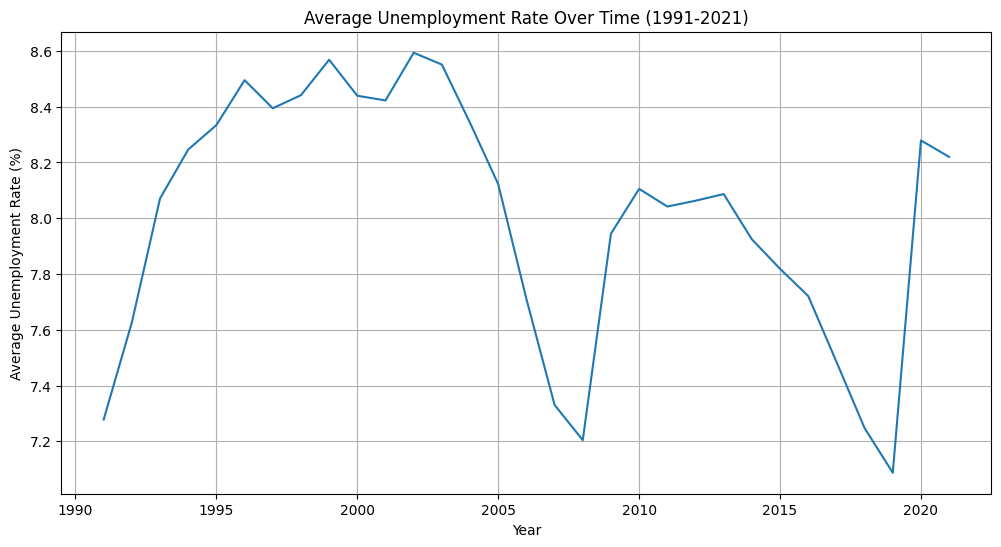

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display descriptive statistics for 'Unemployment Rate'
print("\nDescriptive Statistics for Unemployment Rate:")
print(df_long['Unemployment Rate'].describe())

# Calculate the average unemployment rate per year
average_unemployment_by_year = df_long.groupby('Year')['Unemployment Rate'].mean().reset_index()

# Plot the average unemployment rate over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=average_unemployment_by_year, x='Year', y='Unemployment Rate')
plt.title('Average Unemployment Rate Over Time (1991-2021)')
plt.xlabel('Year')
plt.ylabel('Average Unemployment Rate (%)')
plt.grid(True)
plt.show()

### Country-Specific Unemployment Analysis

Now, let's identify and visualize countries with the highest and lowest average unemployment rates.

/tmp/ipykernel_8770/1832416959.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='Unemployment Rate', y='Country Name', data=top_5_highest_unemployment, palette='viridis')
/tmp/ipykernel_8770/1832416959.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='Unemployment Rate', y='Country Name', data=top_5_lowest_unemployment, palette='magma')


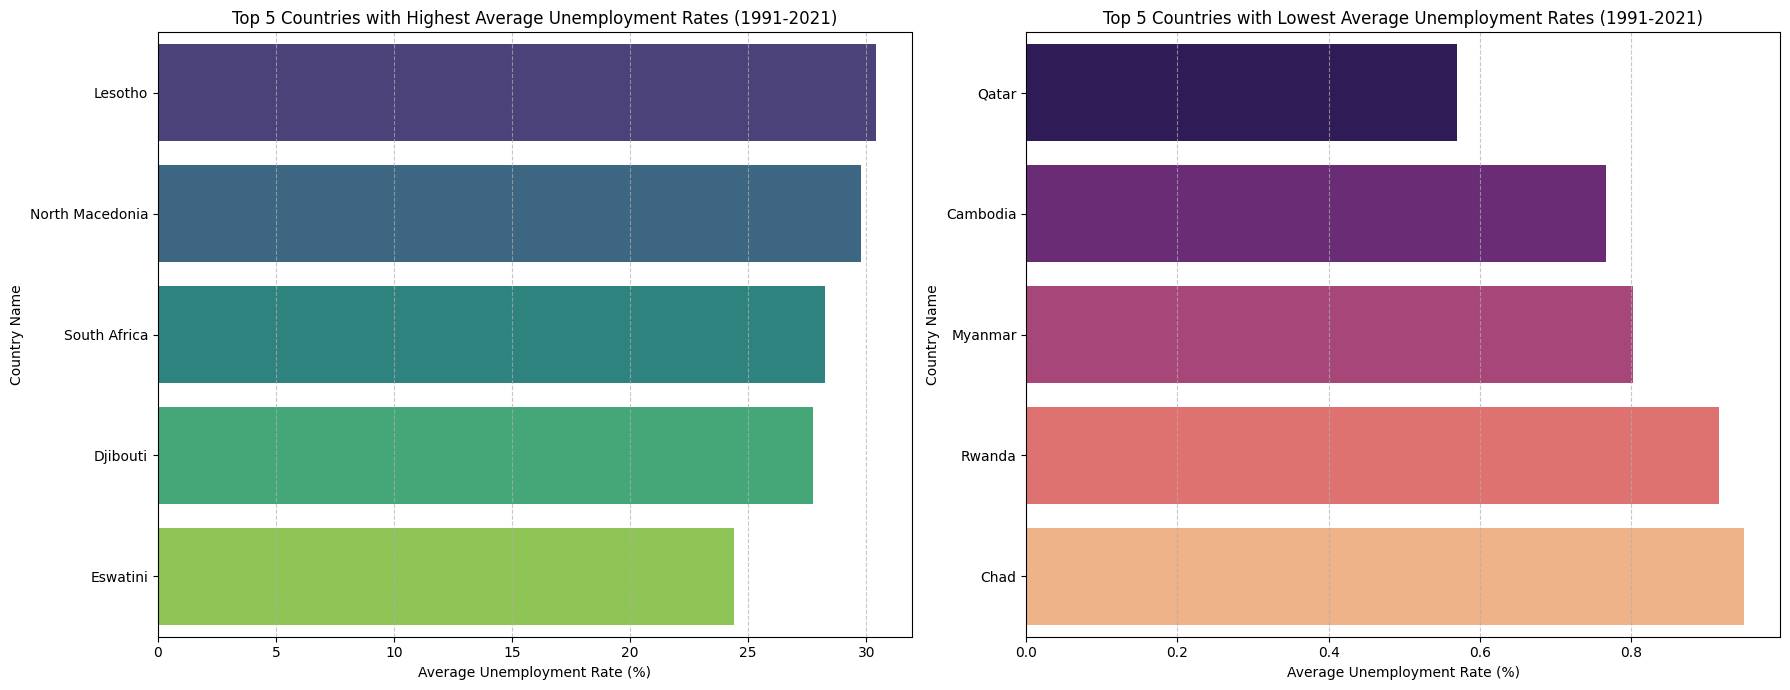

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average unemployment rate for each country
country_average_unemployment = df_long.groupby('Country Name')['Unemployment Rate'].mean().reset_index()

# Sort to get the top 5 countries with the highest unemployment rates
top_5_highest_unemployment = country_average_unemployment.nlargest(5, 'Unemployment Rate')

# Sort to get the top 5 countries with the lowest unemployment rates
top_5_lowest_unemployment = country_average_unemployment.nsmallest(5, 'Unemployment Rate')

# Create subplots for visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot for Top 5 Highest Unemployment Rates
sns.barplot(ax=axes[0], x='Unemployment Rate', y='Country Name', data=top_5_highest_unemployment, palette='viridis')
axes[0].set_title('Top 5 Countries with Highest Average Unemployment Rates (1991-2021)')
axes[0].set_xlabel('Average Unemployment Rate (%)')
axes[0].set_ylabel('Country Name')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# Plot for Top 5 Lowest Unemployment Rates
sns.barplot(ax=axes[1], x='Unemployment Rate', y='Country Name', data=top_5_lowest_unemployment, palette='magma')
axes[1].set_title('Top 5 Countries with Lowest Average Unemployment Rates (1991-2021)')
axes[1].set_xlabel('Average Unemployment Rate (%)')
axes[1].set_ylabel('Country Name')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Investigating COVID-19 Impact on Unemployment Rates

To understand the impact of COVID-19, let's analyze the unemployment trends for the years leading up to, during, and immediately after the pandemic (e.g., 2019-2021).

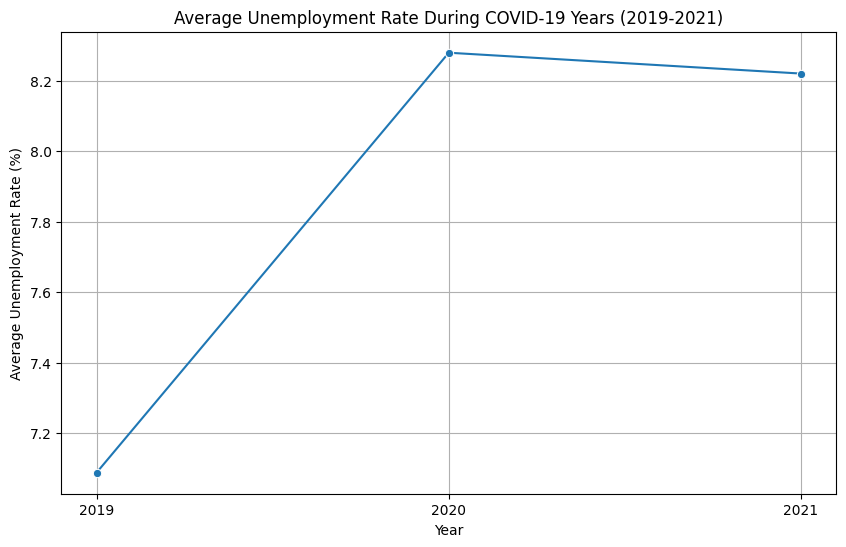

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for years 2019, 2020, and 2021
covid_years_df = df_long[df_long['Year'].isin([2019, 2020, 2021])]

# Calculate the average unemployment rate for these years
average_unemployment_covid = covid_years_df.groupby('Year')['Unemployment Rate'].mean().reset_index()

# Plotting the average unemployment rate during COVID-19 years
plt.figure(figsize=(10, 6))
sns.lineplot(data=average_unemployment_covid, x='Year', y='Unemployment Rate', marker='o')
plt.title('Average Unemployment Rate During COVID-19 Years (2019-2021)')
plt.xlabel('Year')
plt.ylabel('Average Unemployment Rate (%)')
plt.grid(True)
plt.xticks([2019, 2020, 2021])
plt.show()


This plot shows the general trend. Now, let's look at the percentage change in unemployment rates from 2019 (pre-COVID) to 2020 (peak COVID impact) and from 2020 to 2021 to identify countries that experienced the most significant shifts.

In [11]:
# Calculate unemployment rate for 2019, 2020, and 2021 for each country
unemployment_pivot = df_long[df_long['Year'].isin([2019, 2020, 2021])].pivot_table(
    index='Country Name', columns='Year', values='Unemployment Rate'
).reset_index()

# Rename columns for easier access
unemployment_pivot.columns.name = None
unemployment_pivot = unemployment_pivot.rename(columns={2019: 'Unemployment_2019', 2020: 'Unemployment_2020', 2021: 'Unemployment_2021'})

# Calculate percentage change from 2019 to 2020 (COVID impact)
unemployment_pivot['Change_2019_2020'] = ((unemployment_pivot['Unemployment_2020'] - unemployment_pivot['Unemployment_2019']) / unemployment_pivot['Unemployment_2019']) * 100

# Calculate percentage change from 2020 to 2021 (Post-COVID recovery/continued impact)
unemployment_pivot['Change_2020_2021'] = ((unemployment_pivot['Unemployment_2021'] - unemployment_pivot['Unemployment_2020']) / unemployment_pivot['Unemployment_2020']) * 100

# Display countries with the largest increase in unemployment from 2019 to 2020
print("\nTop 10 Countries with Largest Unemployment Rate Increase (2019-2020):")
display(unemployment_pivot.nlargest(10, 'Change_2019_2020'))

# Display countries with the largest decrease in unemployment from 2020 to 2021 (recovery)
print("\nTop 10 Countries with Largest Unemployment Rate Decrease (2020-2021):")
display(unemployment_pivot.nsmallest(10, 'Change_2020_2021'))



Top 10 Countries with Largest Unemployment Rate Increase (2019-2020):


,Country Name,Unemployment_2019,Unemployment_2020,Unemployment_2021,Change_2019_2020,Change_2020_2021
166,Panama,4.73,12.85,12.09,171.670190,-5.914397
30,Cambodia,0.15,0.33,0.61,120.000000,84.848485
222,United States,3.67,8.05,5.46,119.346049,-32.173913
169,Peru,3.38,7.18,4.83,112.426036,-32.729805
149,Myanmar,0.50,1.06,2.17,112.000000,104.716981
158,North America,3.89,8.21,5.70,111.053985,-30.572473
176,Qatar,0.10,0.21,0.26,110.000000,23.809524
21,Bolivia,3.82,7.90,8.51,106.806283,7.721519
90,"Hong Kong SAR, China",2.93,5.83,5.32,98.976109,-8.747856
32,Canada,5.66,9.46,7.51,67.137809,-20.613108



Top 10 Countries with Largest Unemployment Rate Decrease (2020-2021):


,Country Name,Unemployment_2019,Unemployment_2020,Unemployment_2021,Change_2019_2020,Change_2020_2021
77,Georgia,11.57,18.50,10.66,59.896283,-42.378378
169,Peru,3.38,7.18,4.83,112.426036,-32.729805
222,United States,3.67,8.05,5.46,119.346049,-32.173913
158,North America,3.89,8.21,5.70,111.053985,-30.572473
98,India,5.27,8.00,5.98,51.802657,-25.250000
129,Luxembourg,5.59,6.77,5.23,21.109123,-22.747415
9,Australia,5.16,6.46,5.11,25.193798,-20.897833
32,Canada,5.66,9.46,7.51,67.137809,-20.613108
193,South Asia,5.02,7.24,5.79,44.223108,-20.027624
194,South Asia (IDA & IBRD),5.02,7.24,5.79,44.223108,-20.027624


### Year-over-Year Change in Average Unemployment Rate

To identify patterns, let's analyze the year-over-year percentage change in the average unemployment rate. This will highlight periods of significant increases or decreases.

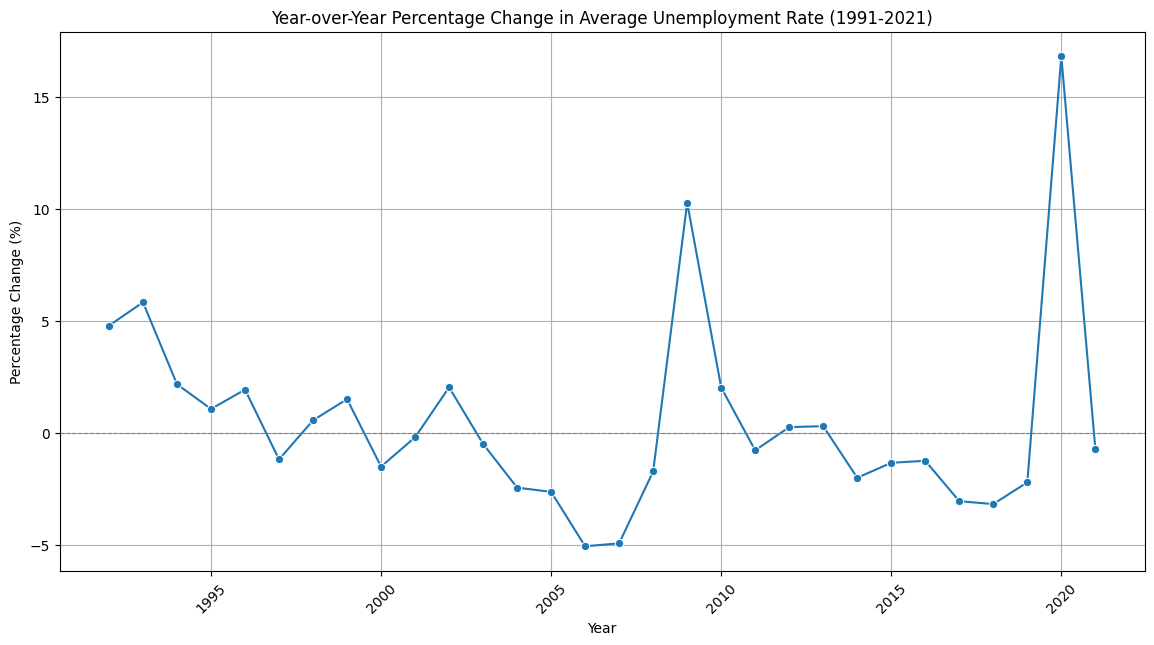

Top 5 years with the largest increase in average unemployment rate:


,Year,Unemployment Rate,Unemployment Rate Change (%)
29,2020,8.278809,16.810865
18,2009,7.944426,10.275372
2,1993,8.070766,5.827507
1,1992,7.626340,4.786211
3,1994,8.246043,2.171747



Top 5 years with the largest decrease in average unemployment rate:


,Year,Unemployment Rate,Unemployment Rate Change (%)
15,2006,7.710511,-5.064863
16,2007,7.330340,-4.930545
27,2018,7.247404,-3.179521
26,2017,7.485404,-3.051096
14,2005,8.121872,-2.635311


In [12]:
# Calculate year-over-year percentage change in average unemployment rate
YoY_change = average_unemployment_by_year.copy()
YoY_change['Unemployment Rate Change (%)'] = YoY_change['Unemployment Rate'].pct_change() * 100

# Drop the first row which will have NaN due to pct_change()
YoY_change = YoY_change.dropna()

plt.figure(figsize=(14, 7))
sns.lineplot(data=YoY_change, x='Year', y='Unemployment Rate Change (%)', marker='o')
plt.title('Year-over-Year Percentage Change in Average Unemployment Rate (1991-2021)')
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Add a zero line
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

print("Top 5 years with the largest increase in average unemployment rate:")
display(YoY_change.nlargest(5, 'Unemployment Rate Change (%)'))

print("\nTop 5 years with the largest decrease in average unemployment rate:")
display(YoY_change.nsmallest(5, 'Unemployment Rate Change (%)'))

### Distribution of Unemployment Rates Over Different Decades

To observe how the overall pattern of unemployment rates has shifted over longer periods, let's visualize the distribution using box plots for different decades.

/tmp/ipykernel_8770/34337652.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x='Decade', y='Unemployment Rate', palette='coolwarm')


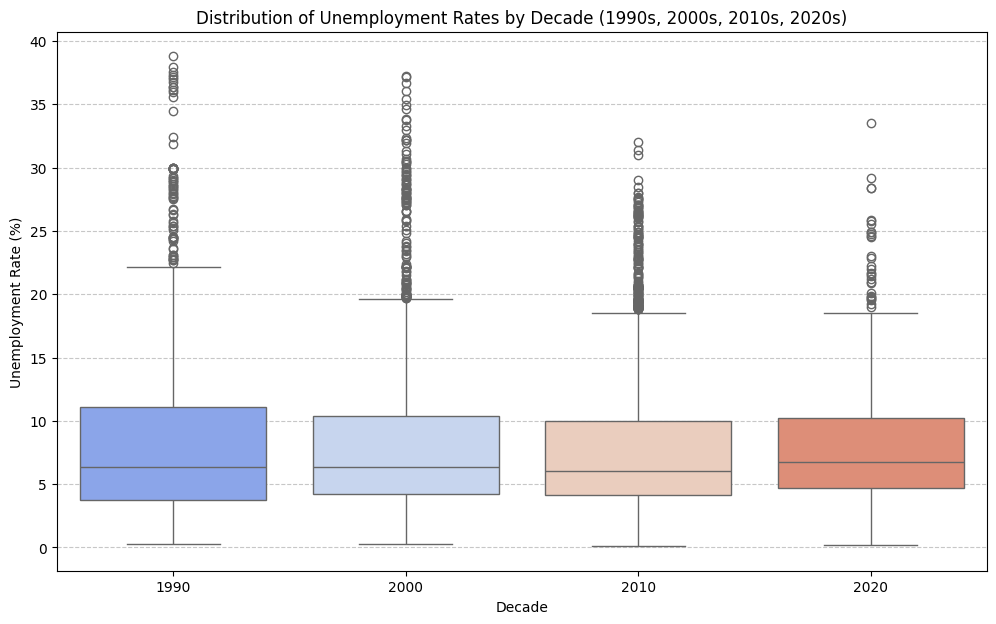

In [13]:
# Create a 'Decade' column for grouping
df_long['Decade'] = (df_long['Year'] // 10) * 10

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_long, x='Decade', y='Unemployment Rate', palette='coolwarm')
plt.title('Distribution of Unemployment Rates by Decade (1990s, 2000s, 2010s, 2020s)')
plt.xlabel('Decade')
plt.ylabel('Unemployment Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Visualizing Policy-Relevant Insights

To effectively inform economic and social policies, let's visualize some of the most critical insights derived from our analysis. These visualizations will highlight structural challenges, vulnerabilities to global shocks, and long-term trends.

#### Insight 1: Persistent Extreme Unemployment Rates

**Policy Relevance:** The stark contrast between countries with persistently very high and very low unemployment rates points to fundamental structural differences that require tailored policy interventions. While some nations successfully maintain near full employment, others struggle with chronic joblessness. Policies should address education, market demand alignment, and economic diversification in high-unemployment regions.

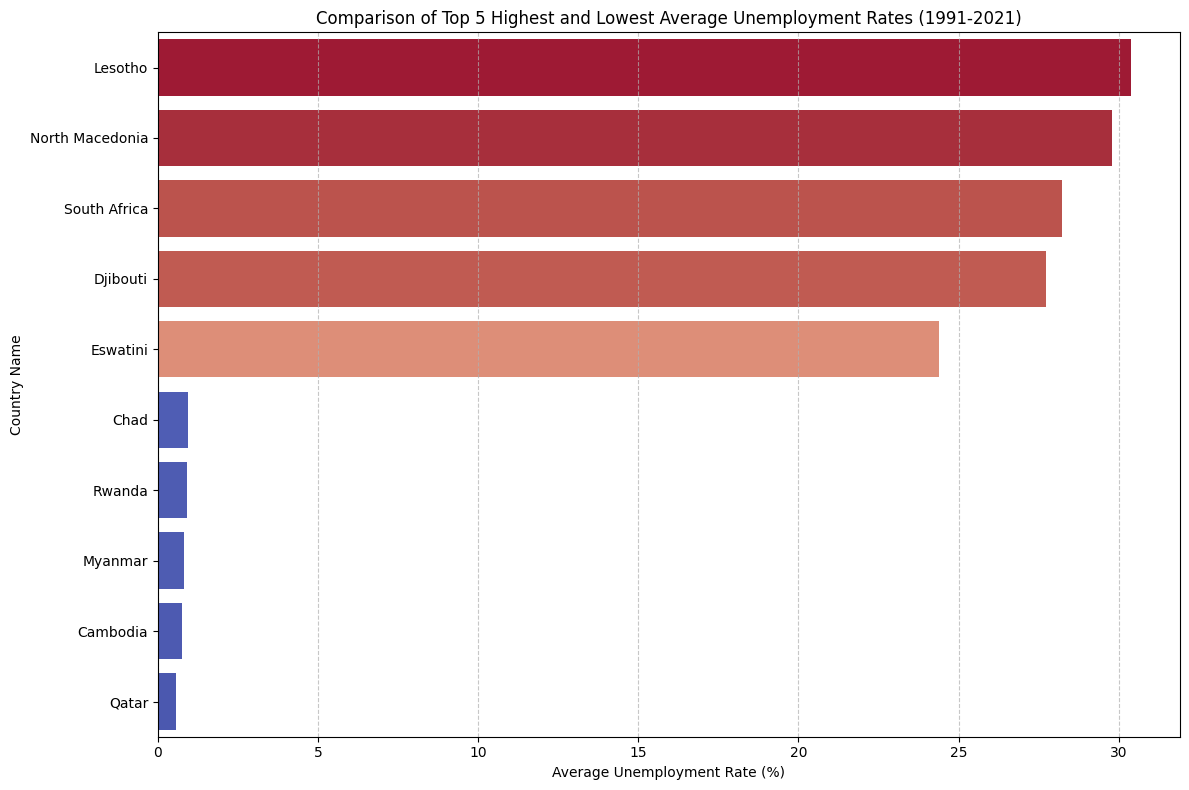

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine top 5 highest and top 5 lowest into a single DataFrame for plotting
combined_unemployment = pd.concat([top_5_highest_unemployment, top_5_lowest_unemployment])

# Sort by unemployment rate for better visualization
combined_unemployment_sorted = combined_unemployment.sort_values(by='Unemployment Rate', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Unemployment Rate', y='Country Name', data=combined_unemployment_sorted,
            palette='coolwarm', hue='Unemployment Rate', legend=False)
plt.title('Comparison of Top 5 Highest and Lowest Average Unemployment Rates (1991-2021)')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('Country Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Insight 2: Varied Impact and Recovery from Global Shocks (e.g., COVID-19)

**Policy Relevance:** Global events like the COVID-19 pandemic have a disproportionate impact, with some economies experiencing massive unemployment surges and others demonstrating quicker recovery. Policies need to focus on building economic resilience, developing adaptable social safety nets, and supporting sectors and regions most vulnerable to external shocks.

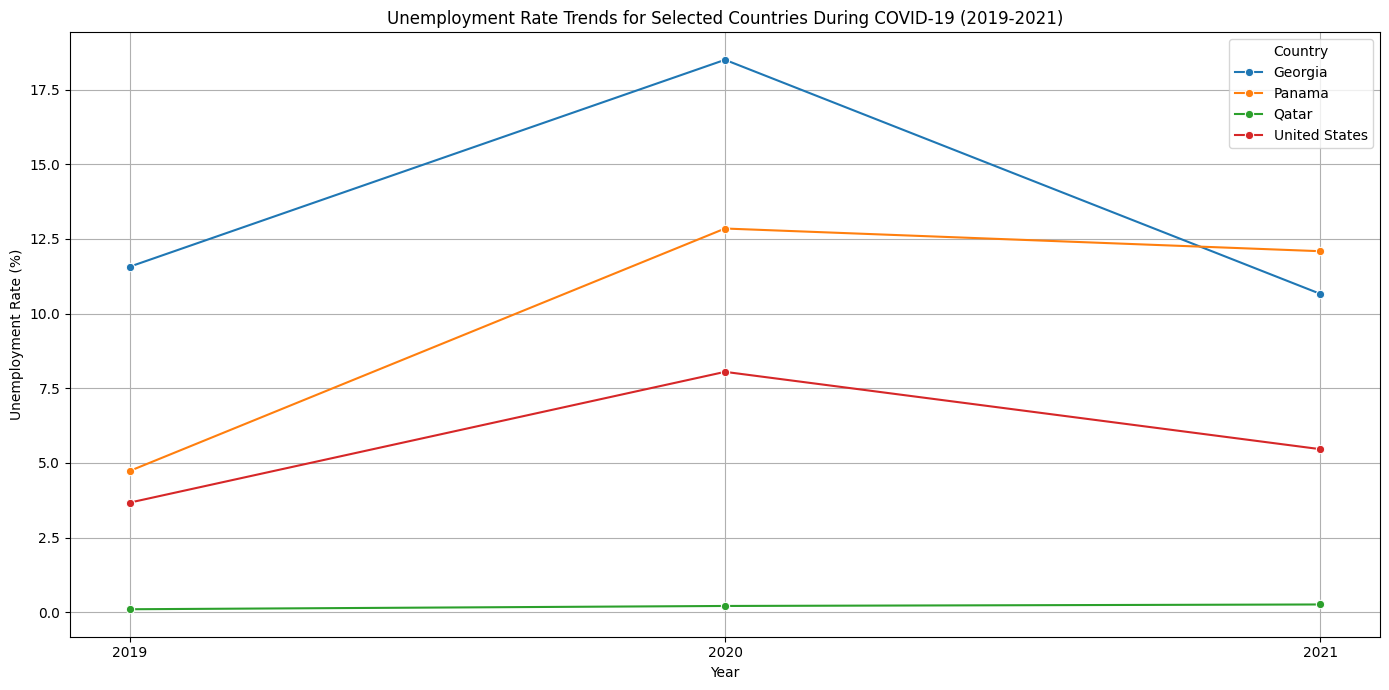

In [15]:
# Select a few key countries to illustrate varied COVID-19 impact
selected_countries_covid = ['Panama', 'United States', 'Qatar', 'Georgia'] # Panama (high increase, moderate recovery), US (high increase, good recovery), Qatar (low but still spike), Georgia (strong recovery)

covid_impact_countries_df = df_long[(df_long['Year'].isin([2019, 2020, 2021])) &
                                    (df_long['Country Name'].isin(selected_countries_covid))]

plt.figure(figsize=(14, 7))
sns.lineplot(data=covid_impact_countries_df, x='Year', y='Unemployment Rate', hue='Country Name', marker='o')
plt.title('Unemployment Rate Trends for Selected Countries During COVID-19 (2019-2021)')
plt.xlabel('Year')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True)
plt.xticks([2019, 2020, 2021])
plt.legend(title='Country')
plt.tight_layout()
plt.show()

#### Insight 3: Long-Term Decadal Shifts and Cyclical Patterns

**Policy Relevance:** The distribution of unemployment rates across decades highlights long-term shifts and the recurring nature of economic cycles. The overall improvement seen in the 2010s, followed by the disruption in the early 2020s, underscores the need for proactive and adaptive economic governance. Policies should include counter-cyclical measures, continuous investment in human capital, and fostering innovation to maintain competitiveness through various economic phases.

*Refer back to the **Distribution of Unemployment Rates by Decade (1990s, 2000s, 2010s, 2020s)** box plot above for a visual representation of this insight.*